<a href="https://colab.research.google.com/github/jurados/alercehackton2026/blob/jurados/ZTF_candidates.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors

In [ ]:
!pip -q install msal requests


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.9/119.9 kB 4.8 MB/s eta 0:00:00


In [ ]:
!pip install astroquery astropy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.6 MB/s eta 0:00:00


In [ ]:
!pip install alerce

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.8 MB/s eta 0:00:00


In [2]:
!pip -q install alerce astropy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from alerce.core import Alerce
from astropy.timeseries import LombScargle
from astropy.coordinates import SkyCoord
import astropy.units as u



In [ ]:
client = Alerce()

cls = client.query_classifiers(format="pandas", survey="ztf")

print(cls.columns)
display(cls.head(20))


Index(['classifier_name', 'classifier_version', 'classes'], dtype='object')


,classifier_name,classifier_version,classes
0,lc_classifier_transient,hierarchical_random_forest_1.0.0,"[SNIa, SNIbc, SNII, SLSN]"
1,lc_classifier_stochastic,hierarchical_random_forest_1.0.0,"[QSO, AGN, Blazar, CV/Nova, YSO]"
2,lc_classifier_periodic,hierarchical_random_forest_1.0.0,"[LPV, E, DSCT, RRL, CEP, Periodic-Other]"
3,LC_classifier_ATAT_forced_phot(beta),beta,"[SNIa, SNIbc, SNIIb, SNII, SNIIn, SLSN, TDE, M..."
4,LC_classifier_BHRF_forced_phot(beta),beta,"[SNIa, SNIbc, SNIIb, SNII, SNIIn, SLSN, TDE, M..."
5,lc_classifier,hierarchical_random_forest_1.0.0,"[SNIa, SNIbc, SNII, SLSN, QSO, AGN, Blazar, CV..."
6,lc_classifier_top,hierarchical_random_forest_1.0.0,"[Transient, Stochastic, Periodic]"
7,stamp_classifier,stamp_classifier_1.0.0,"[SN, AGN, VS, asteroid, bogus]"
8,stamp_classifier,stamp_classifier_1.0.4,"[SN, AGN, VS, asteroid, bogus]"
9,lc_classifier_BHRF_forced_phot,2.1.0,"[SNIa, SESN, SNII, SNIIn, SLSN, TDE, Microlens..."


In [ ]:
client = Alerce()

#1 Sept 2025
START_MJD = 60919

df = client.query_objects(
    survey="ztf",
    classifier="lc_classifier_BHRF_forced_phot",
    class_name="SNIa",
    probability=0.59,
    order_by="lastmjd",
    order_mode="DESC",
    page_size=2000,
    format="pandas"
)

df["lastmjd"] = pd.to_numeric(df["lastmjd"], errors="coerce")

# filtrar
df_snia = df[df["lastmjd"] >= START_MJD]

print("SNIa encontradas:", len(df_snia))

display(df_snia)

SNIa encontradas: 130


,oid,ndethist,ncovhist,mjdstarthist,mjdendhist,corrected,stellar,ndet,g_r_max,g_r_max_corr,...,lastmjd,deltajd,meanra,meandec,sigmara,sigmadec,class,classifier,probability,step_id_corr
0,ZTF26aadonog,41,932,61061.501713,61111.519549,True,False,37,None,None,...,61111.519549,50.017836,195.152333,-6.474194,0.003444,0.003422,SNIa,lc_classifier_BHRF_forced_phot,0.663984,27.5.7a32.dev1
1,ZTF26aabkqap,35,881,61055.553206,61111.518588,False,False,35,None,None,...,61111.518588,55.965382,203.263061,-16.241590,0.003574,0.003432,SNIa,lc_classifier_BHRF_forced_phot,0.610416,27.5.7a32.dev1
2,ZTF25acldfsf,65,1934,61038.504873,61111.464016,False,False,62,None,None,...,61111.464016,72.959143,218.473272,5.460067,0.002695,0.002683,SNIa,lc_classifier_BHRF_forced_phot,0.622740,27.5.7a32.dev1
3,ZTF26aadsezg,121,2965,61065.412280,61111.450440,False,False,58,None,None,...,61111.450440,46.038160,184.384761,13.836323,0.003117,0.003026,SNIa,lc_classifier_BHRF_forced_phot,0.730536,27.5.7a32.dev1
4,ZTF26aadsfln,127,3513,61061.453275,61111.449977,False,False,85,None,None,...,61111.449977,49.995752,188.912750,5.039380,0.002852,0.002841,SNIa,lc_classifier_BHRF_forced_phot,0.620000,27.5.7a32.dev1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,ZTF25aascfmn,91,3363,60821.330197,60922.207419,False,False,68,None,None,...,60922.207419,100.877222,276.762999,51.053522,0.014309,0.008995,SNIa,lc_classifier_BHRF_forced_phot,0.760000,27.5.6
126,ZTF25abbshoi,37,2136,60873.239514,60920.172257,False,False,39,None,None,...,60920.172257,46.932743,283.543081,41.295738,0.015511,0.011654,SNIa,lc_classifier_BHRF_forced_phot,0.718000,27.5.6
127,ZTF25abcfyxt,108,1792,60875.399525,60919.353299,False,False,99,None,None,...,60919.353299,42.931771,348.134379,-0.207635,0.003053,0.003053,SNIa,lc_classifier_BHRF_forced_phot,0.746000,27.5.6
128,ZTF25aatvtvy,56,1572,60831.383391,60919.350475,False,False,39,None,None,...,60919.350475,87.967083,349.269353,18.599774,0.012550,0.011894,SNIa,lc_classifier_BHRF_forced_phot,0.641712,27.5.6


In [ ]:
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 

In [40]:
df_snia= pd.read_pickle("df_snia_ztf_new.pkl")


tns = pd.read_csv("tns_public_objects.csv", skiprows=1, low_memory=False)

tns["ra"] = pd.to_numeric(tns["ra"], errors="coerce")
tns["declination"] = pd.to_numeric(tns["declination"], errors="coerce")
tns["redshift"] = pd.to_numeric(tns["redshift"], errors="coerce")

tns = tns.dropna(subset=["ra", "declination"]).reset_index(drop=True)



print("\nBuscando columnas de coordenadas en df_snia...")
for col in df_snia.columns:
    cl = col.lower()
    if "ra" in cl or "dec" in cl:
        print(col)

# Ajusta esto si tus columnas tienen otro nombre
ra_col = "ra"
dec_col = "dec"

df_snia[ra_col] = pd.to_numeric(df_snia[ra_col], errors="coerce")
df_snia[dec_col] = pd.to_numeric(df_snia[dec_col], errors="coerce")

df_snia = df_snia.dropna(subset=[ra_col, dec_col]).reset_index(drop=True)


#print("Objetos en TNS:", len(tns))
#display(tns.head())

# Cambbio de coordenadas
coords_snia = SkyCoord(
    ra=df_snia["ra"].values * u.deg,
    dec=df_snia["dec"].values * u.deg
)

coords_tns = SkyCoord(
    ra=tns["ra"].values * u.deg,
    dec=tns["declination"].values * u.deg
)

#match
idx, sep2d, _ = coords_snia.match_to_catalog_sky(coords_tns)

# umbral de matching
max_sep = 2.0 * u.arcsec
matched = sep2d <= max_sep


df_snia["tns_match"] = matched
df_snia["tns_sep_arcsec"] = sep2d.arcsec

df_snia["tns_name"] = np.where(
    matched,
    tns.iloc[idx]["name"].values,
    None
)

df_snia["tns_name_prefix"] = np.where(
    matched,
    tns.iloc[idx]["name_prefix"].values,
    None
)

df_snia["tns_type"] = np.where(
    matched,
    tns.iloc[idx]["type"].values,
    None
)

df_snia["tns_redshift"] = np.where(
    matched,
    tns.iloc[idx]["redshift"].values,
    np.nan
)

df_snia["tns_full_name"] = np.where(
    matched,
    df_snia["tns_name_prefix"].astype(str) + " " + df_snia["tns_name"].astype(str),
    None
)

print("\nMatches encontrados:", int(df_snia["tns_match"].sum()))
display(df_snia.head())


output_file = "df_snia_with_tns_match.csv"
df_snia.to_csv(output_file, index=False)

print(f"\n Guardado: {output_file}")


Buscando columnas de coordenadas en df_snia...
ra
dec

Matches encontrados: 63995


,oid,mjd,fid,magpsf,sigmapsf,ra,dec,tid,tns_match,tns_sep_arcsec,tns_name,tns_name_prefix,tns_type,tns_redshift,tns_full_name
0,ZTF20acobvxk,59149.448125,1,19.810800,0.236357,37.673496,-14.569211,ztf,True,0.299260,2020ymv,SN,SN Ia,0.08,SN 2020ymv
1,ZTF20acobvxk,59151.272535,1,19.568500,0.277572,37.673642,-14.569045,ztf,True,0.578001,2020ymv,SN,SN Ia,0.08,SN 2020ymv
2,ZTF20acobvxk,59151.350405,2,19.385900,0.217224,37.673397,-14.569204,ztf,True,0.450946,2020ymv,SN,SN Ia,0.08,SN 2020ymv
3,ZTF20acobvxk,59152.264155,1,19.226200,0.222367,37.673513,-14.568956,ztf,True,0.621037,2020ymv,SN,SN Ia,0.08,SN 2020ymv
4,ZTF20acobvxk,59153.332118,2,18.783262,0.167610,37.673557,-14.569205,ztf,True,0.344176,2020ymv,SN,SN Ia,0.08,SN 2020ymv



 Guardado: df_snia_with_tns_match.csv


In [41]:
from google.colab import files
files.download("df_snia_with_tns_match.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

TABLA COMPLETA

In [ ]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
display(df_snia)

,oid,ndethist,ncovhist,mjdstarthist,mjdendhist,corrected,stellar,ndet,g_r_max,g_r_max_corr,g_r_mean,g_r_mean_corr,firstmjd,lastmjd,deltajd,meanra,meandec,sigmara,sigmadec,class,classifier,probability,step_id_corr,tns_match,tns_sep_arcsec,tns_name,tns_name_prefix,tns_type,tns_redshift,tns_full_name
0,ZTF26aadonog,41,932,61061.501713,61111.519549,True,False,37,None,None,None,None,61061.501713,61111.519549,50.017836,195.152333,-6.474194,0.003444,0.003422,SNIa,lc_classifier_BHRF_forced_phot,0.663984,27.5.7a32.dev1,True,0.048113,2026azd,SN,SN Ia-91T-like,0.015600,SN 2026azd
1,ZTF26aabkqap,35,881,61055.553206,61111.518588,False,False,35,None,None,None,None,61055.553206,61111.518588,55.965382,203.263061,-16.241590,0.003574,0.003432,SNIa,lc_classifier_BHRF_forced_phot,0.610416,27.5.7a32.dev1,True,0.087777,2026amc,SN,SN Ia,0.024107,SN 2026amc
2,ZTF25acldfsf,65,1934,61038.504873,61111.464016,False,False,62,None,None,None,None,61038.504873,61111.464016,72.959143,218.473272,5.460067,0.002695,0.002683,SNIa,lc_classifier_BHRF_forced_phot,0.622740,27.5.7a32.dev1,True,0.104226,2025ajnc,SN,SN Ia,0.024931,SN 2025ajnc
3,ZTF26aadsezg,121,2965,61065.412280,61111.450440,False,False,58,None,None,None,None,61065.412280,61111.450440,46.038160,184.384761,13.836323,0.003117,0.003026,SNIa,lc_classifier_BHRF_forced_phot,0.730536,27.5.7a32.dev1,True,0.154229,2026bhf,SN,SN Ia,0.065142,SN 2026bhf
4,ZTF26aadsfln,127,3513,61061.453275,61111.449977,False,False,85,None,None,None,None,61061.454224,61111.449977,49.995752,188.912750,5.039380,0.002852,0.002841,SNIa,lc_classifier_BHRF_forced_phot,0.620000,27.5.7a32.dev1,True,0.261177,2026bhk,SN,SN Ia,0.065226,SN 2026bhk
5,ZTF26aacuoil,34,1076,61059.481643,61111.439595,False,False,32,None,None,None,None,61059.481643,61111.439595,51.957951,190.836141,-16.525708,0.003586,0.003438,SNIa,lc_classifier_BHRF_forced_phot,0.662656,27.5.7a32.dev1,True,0.012810,2026auf,SN,SN Ia,0.033000,SN 2026auf
6,ZTF26aabjpnx,103,2024,61055.411100,61111.383484,True,False,70,None,None,None,None,61056.297303,61111.383484,55.086181,144.567300,26.688919,0.002715,0.002426,SNIa,lc_classifier_BHRF_forced_phot,0.657312,27.5.7a32.dev1,True,0.162457,2026akn,SN,SN Ia,0.043354,SN 2026akn
7,ZTF26aafqpqd,42,1313,61079.277813,61111.353044,False,False,34,None,None,None,None,61079.277813,61111.353044,32.075231,160.139402,2.489350,0.003652,0.003649,SNIa,lc_classifier_BHRF_forced_phot,0.678640,27.5.7a32.dev1,True,0.237221,2026cli,SN,SN Ia,0.081540,SN 2026cli
8,ZTF25acitiuq,205,3513,61025.433889,61111.350660,True,False,153,None,None,None,None,61025.433889,61111.350660,85.916771,141.426895,22.334934,0.001964,0.001816,SNIa,lc_classifier_BHRF_forced_phot,0.615568,27.5.7a32.dev1,True,0.197354,2025ahkt,SN,SN Ia,0.026228,SN 2025ahkt
9,ZTF26aagdhiy,56,3781,61080.256655,61111.327130,False,False,53,None,None,None,None,61080.256655,61111.327130,31.070475,134.755690,17.396073,0.010434,0.009957,SNIa,lc_classifier_BHRF_forced_phot,0.652000,27.5.7a32.dev1,True,0.024915,2026crq,SN,SN Ia,0.090634,SN 2026crq


In [ ]:
output_file = "df_snia_with_tns_match.csv"
df_snia.to_csv(output_file, index=False)

print("Archivo guardado:", output_file)

from google.colab import files
files.download("df_snia_with_tns_match.csv")

Archivo guardado: df_snia_with_tns_match.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

LIGHT CURVES

In [ ]:
import os

client = Alerce()

outdir = "lightcurves_snia"
os.makedirs(outdir, exist_ok=True)

all_lcs = []

for oid in df_snia["oid"]:
    try:
        det = client.query_detections(oid, format="pandas")

        forced = client.query_non_detections(oid, format="pandas")

        if det is not None and len(det) > 0:
            det = det.copy()
            det["oid"] = oid

            det.to_csv(f"{outdir}/{oid}_detections.csv", index=False)

            all_lcs.append(det)

        else:
            print(f"Sin detections para {oid}")

    except Exception as e:
        print(f"Error con {oid}: {e}")

if len(all_lcs) > 0:
    df_all_lcs = pd.concat(all_lcs, ignore_index=True)
    output_file = "all_snia_lightcurves.csv"
    df_all_lcs.to_csv(output_file, index=False)

    print(f"Total filas: {len(df_all_lcs)}")
else:
    print("No se pudo descargar ninguna curva de luz")

Total filas: 6115


In [ ]:
from google.colab import files
files.download("all_snia_lightcurves.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
oid_selected = "ZTF25abhibmk"#"ZTF25abqamzb"

det = client.query_detections(oid_selected, format="pandas")

if det is not None and len(det) > 0:
    det = det.copy()
    det["oid"] = oid_selected

    output_file = f"{oid_selected}_lightcurve.csv"
    det.to_csv(output_file, index=False)

    print(f"Curva de luz guardada: {output_file}")
    print(f"Total puntos: {len(det)}")
    display(det.head())
else:
    print(f"No se encontraron detections para {oid_selected}")

Curva de luz guardada: ZTF25abhibmk_lightcurve.csv
Total puntos: 28


,tid,mjd,candid,fid,pid,diffmaglim,isdiffpos,nid,distnr,magpsf,...,sigmagapbig,has_stamp,corrected,dubious,step_id_corr,phase,parent_candid,drb,rfid,oid
0,ztf,60891.285949,3137285940215015009,1,3137285940215,20.164800,1,3137,2.392220,20.104400,...,0.4713,False,False,False,27.5.6,0.0,3.166371e+18,NaN,NaN,ZTF25abhibmk
1,ztf,60894.427199,3140427190215015010,1,3140427190215,19.563194,1,3140,2.320466,19.427711,...,0.5605,True,False,False,27.5.6,0.0,NaN,0.998350,544120102.0,ZTF25abhibmk
2,ztf,60896.297755,3142297750215015006,2,3142297750215,18.992600,1,3142,2.603710,19.209400,...,0.3341,False,False,False,27.5.6,0.0,3.166371e+18,NaN,NaN,ZTF25abhibmk
3,ztf,60896.449595,3142449590215015012,1,3142449590215,18.529700,1,3142,2.377090,19.104200,...,0.3385,False,False,False,27.5.6,0.0,3.166371e+18,NaN,NaN,ZTF25abhibmk
4,ztf,60898.369039,3144369030215015006,2,3144369030215,19.332325,1,3144,2.534687,19.265413,...,0.4257,True,False,False,27.5.6,0.0,NaN,0.999879,544120202.0,ZTF25abhibmk


In [ ]:
# CON ESTO DESCARGAS
from google.colab import files
files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_361/1711213418.py:26: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x, y, deg)
/tmp/ipykernel_361/1711213418.py:59: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x, y, deg)


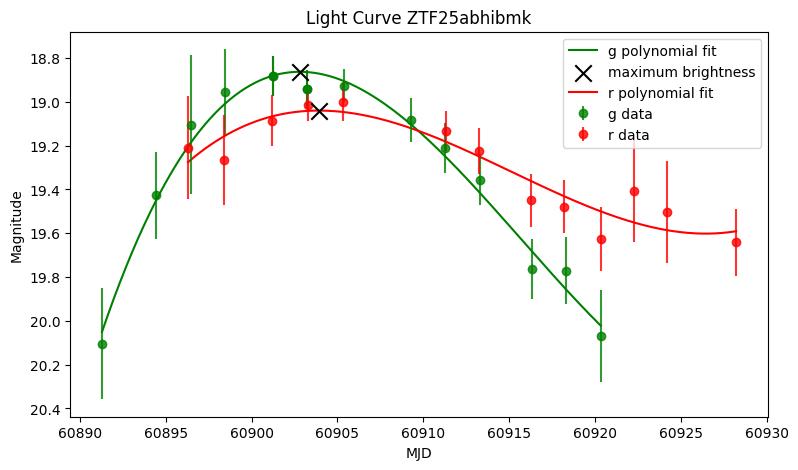

60902.81842862605 18.863027572631836 60903.91137977511 19.0401029586792


In [ ]:
g = det[det["fid"] == 1].copy()
r = det[det["fid"] == 2].copy()

plt.figure(figsize=(9,5))


plt.errorbar(
    g["mjd"], g["magpsf"], yerr=g["sigmapsf"],
    fmt="o", color="green", label="g data",
    alpha=0.8, zorder=2
)

plt.errorbar(
    r["mjd"], r["magpsf"], yerr=r["sigmapsf"],
    fmt="o", color="red", label="r data",
    alpha=0.8, zorder=2
)

deg = 5

# g
if len(g) > deg:

    x = g["mjd"].values
    y = g["magpsf"].values

    p = np.polyfit(x, y, deg)
    poly = np.poly1d(p)

    xfit = np.linspace(x.min(), x.max(), 500)
    yfit = poly(xfit)

    plt.plot(
        xfit, yfit,
        color="green",
        label="g polynomial fit",
        zorder=1
    )

    i = np.argmin(yfit)
    x_max_g = xfit[i]
    y_max_g = yfit[i]

    plt.scatter(
        x_max_g, y_max_g,
        color="black",
        marker="x",
        s=140,
        zorder=5,
        label="maximum brightness"
    )


# r
if len(r) > deg:

    x = r["mjd"].values
    y = r["magpsf"].values

    p = np.polyfit(x, y, deg)
    poly = np.poly1d(p)

    xfit = np.linspace(x.min(), x.max(), 500)
    yfit = poly(xfit)

    plt.plot(
        xfit, yfit,
        color="red",
        label="r polynomial fit",
        zorder=1
    )

    i = np.argmin(yfit)
    x_max_r = xfit[i]
    y_max_r = yfit[i]

    plt.scatter(
        x_max_r, y_max_r,
        color="black",
        marker="x",
        s=140,
        zorder=5
    )


plt.gca().invert_yaxis()
plt.xlabel("MJD")
plt.ylabel("Magnitude")
plt.title(f"Light Curve {oid_selected}")

plt.legend()
plt.show()

print(x_max_g, y_max_g, x_max_r, y_max_r)

# CÁLCULO DE H_0



In [ ]:
!pip install sncosmo

In [ ]:
!pip install iminuit
import iminuit

In [ ]:
import pandas as pd
import numpy as np
import sncosmo
from astropy.table import Table


#http://www.aerith.net/astro/color_conversion.html (NOT SURE)

def procesar_supernova_desde_df(df, survey, z_host, M_B_calibrado=-19.253):
    """
    Toma un DataFrame de Pandas, lo adapta para sncosmo y calcula H0.
    survey: 'ztf' o 'lsst' (para saber cómo mapear bandas y zero points)
    """

    # 1. Copiamos para no modificar el original
    df_sn = df.copy()

    # 2. Mapeo de Bandas y Configuración según el Telescopio
    if survey.lower() == 'ztf':
        # ZTF suele venir en magnitudes (magpsf)
        band_map = {1: 'ztfg', 2: 'ztfr', 3: 'ztfi'}
        df_sn['band'] = df_sn['fid'].map(band_map)

        # Convertir Mag a Flujo (usando ZP=25 como estándar)
        df_sn['flux'] = 10**((25 - df_sn['magpsf']) / 2.5)
        df_sn['fluxerr'] = df_sn['sigmapsf'] * df_sn['flux'] * (np.log(10)/2.5)
        df_sn['zp'] = 25
        df_sn['zpsys'] = 'ab'

    elif survey.lower() == 'lsst':
        # LSST suele venir en flujo (nanoJanskys)
        band_map = {1: 'lsstg', 2: 'lsstr', 3: 'lssti', 4: 'lsstz', 5: 'lssty', 6: 'lsstu'}
        df_sn['band'] = df_sn['band'].map(band_map)

        # Si ya es flujo, solo renombramos
        df_sn = df_sn.rename(columns={'psfFlux': 'flux', 'psfFluxErr': 'fluxerr'})
        df_sn['zp'] = 31.4 # ZP para nanoJanskys
        df_sn['zpsys'] = 'ab'

    # 3. Limpieza: eliminar filas con bandas que no pudimos mapear o valores nulos
    df_sn = df_sn.dropna(subset=['band', 'flux', 'fluxerr'])

    # 4. CONVERSIÓN CRÍTICA: Pandas -> Astropy Table
    # Solo pasamos las columnas que sncosmo necesita
    data_table = Table.from_pandas(df_sn[['mjd', 'band', 'flux', 'fluxerr', 'zp', 'zpsys']])

    # 5. AJUSTE Y CÁLCULO DE H0 (Usando la lógica anterior)
    model = sncosmo.Model(source='salt3')
    model.set(z=z_host)

    try:
        result, fitted_model = sncosmo.fit_lc(
            data_table, model,
            ['t0', 'x0', 'x1', 'c'],
            bounds={'x1': (-3, 3), 'c': (-0.3, 0.3)}
        )

        m_b = fitted_model.bandmag('standard::b', 'ab', result.parameters[1])
        mu = m_b - (M_B_calibrado - 0.14 * result.parameters[3] + 3.1 * result.parameters[4])
        d_L = 10**((mu - 25) / 5)
        h0 = (299792.458 * z_host) / d_L

        return h0, result, fitted_model

    except Exception as e:
        print(f"Error en el ajuste: {e}")
        return None, None, None

# --- MODO DE USO CON CSV ---

# 1. Cargar tus archivos
# df_ztf = pd.read_csv("mis_datos_ztf.csv")

# 2. Ejecutar la función
# h0_resultado, res, fit = procesar_supernova_desde_df(df_ztf, survey='ztf', z_host=0.045)

# if h0_resultado:
#    print(f"H0 calculado: {h0_resultado:.2f}")
# Ejemplo:
# h0_val, mu_val = estimar_constante_hubble(tu_tabla_data, z_host=0.045)

In [ ]:
df_ztf = pd.read_csv("ZTF25abhibmk_lightcurve.csv")#ZTF25abqamzb_lightcurve.csv")

h0_val, res, fit = procesar_supernova_desde_df(df_ztf, survey='ztf', z_host=0.08, M_B_calibrado=-19.25)
print(h0_val, res, fit)

53.95827640097872       success: True
      message: 'Minimization exited successfully.'
        ncall: 88
        chisq: 5.376186469022159
         ndof: 24
  param_names: ['z', 't0', 'x0', 'x1', 'c']
   parameters: array([8.00000000e-02, 6.09032980e+04, 4.15006322e-04, 2.68534852e-01,
       1.60291493e-02])
 vparam_names: ['t0', 'x0', 'x1', 'c']
   covariance: array([[ 2.17384758e-01, -1.09422772e-06, -3.59001811e-02,
         3.97075430e-04],
       [-1.09422772e-06,  2.13838100e-10, -3.89833973e-06,
        -3.77763334e-07],
       [-3.59001811e-02, -3.89833973e-06,  2.70898039e-01,
         4.58751973e-03],
       [ 3.97075430e-04, -3.77763334e-07,  4.58751973e-03,
         1.34114051e-03]])
       errors: OrderedDict({'t0': 0.4662398842701805, 'x0': 1.4623204154108024e-05, 'x1': 0.5178505152787517, 'c': 0.03653043996378488})
         nfit: 1
    data_mask: array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True

# H_0 para ZTF

In [ ]:
df = pd.read_pickle("df_snia_ztf.pkl")

#print(df.head())
#df["oid"].unique() # nombres de todas
#df["oid"].nunique() # 435 sn

for oid in df["oid"].unique():

    sn = df[df["oid"] == oid]

    g = sn[sn["fid"] == 1]
    r = sn[sn["fid"] == 2]

sn

,oid,mjd,fid,magpsf,sigmapsf,ra,dec,tid
16258,ZTF25acejaxg,61003.340289,2,19.515047,0.128048,27.114177,13.917775,ztf
16259,ZTF25acejaxg,61005.228901,1,19.164940,0.118801,27.114111,13.917804,ztf
16260,ZTF25acejaxg,61005.259375,2,19.144323,0.128013,27.114153,13.917750,ztf
16261,ZTF25acejaxg,61007.235463,1,18.919040,0.101064,27.114128,13.917752,ztf
16262,ZTF25acejaxg,61007.319248,2,18.834690,0.094505,27.114098,13.917743,ztf
16263,ZTF25acejaxg,61009.121366,2,18.682405,0.087576,27.114109,13.917772,ztf
16264,ZTF25acejaxg,61009.261285,1,18.763424,0.106588,27.114116,13.917782,ztf
16265,ZTF25acejaxg,61013.190706,2,18.482952,0.163088,27.114074,13.917663,ztf
16266,ZTF25acejaxg,61013.225347,1,18.461897,0.179814,27.114079,13.917815,ztf
16267,ZTF25acejaxg,61015.230972,1,18.605114,0.118281,27.114148,13.917724,ztf


In [ ]:
import pandas as pd
from astropy.table import Table
import sncosmo

# Load the light curve data from the CSV file
lightcurve_df = pd.read_csv('ZTF25abqamzb_lightcurve.csv')

# Prepare data for sncosmo
# Convert magnitudes and errors to fluxes and flux errors
# Assuming ZP=25, zpsys='ab' for ZTF

lightcurve_df['zp'] = 25.0
lightcurve_df['zpsys'] = 'ab'

# Convert magnitude to flux
lightcurve_df['flux'] = 10**(-0.4 * (lightcurve_df['magpsf'] - lightcurve_df['zp']))
# Convert magnitude error to flux error
# dFlux = -0.4 * ln(10) * Flux * dMag
lightcurve_df['fluxerr'] = np.abs(-0.4 * np.log(10) * lightcurve_df['flux'] * lightcurve_df['sigmapsf'])

# Map fid (filter ID) to band names
band_map = {1: 'ztfg', 2: 'ztfr'}
lightcurve_df['band'] = lightcurve_df['fid'].map(band_map)

# Create an Astropy Table with required columns
data_table = Table.from_pandas(lightcurve_df[['mjd', 'band', 'flux', 'fluxerr', 'zp', 'zpsys']])

# Define the redshift for the object (from the original call)
z_host = 0.08

# Call the function with the prepared Astropy Table
estimar_constante_hubble(data_table, z_host)

--- RESULTADOS PARA Z=0.08 ---
Stretch (x1): 0.227
Color (c):    0.194
Distancia (d_L): 316.46 Mpc
VALOR DE H0: 75.79 km/s/Mpc


(np.float64(75.78613942486601), np.float64(37.501604527093754))

In [ ]:
for oid in df["oid"].unique():

    sn = df[df["oid"] == oid]

    g = sn[sn["fid"] == 1]
    r = sn[sn["fid"] == 2]

    plt.figure()

    plt.errorbar(g["mjd"], g["magpsf"], yerr=g["sigmapsf"], fmt="o", label="g")
    plt.errorbar(r["mjd"], r["magpsf"], yerr=r["sigmapsf"], fmt="o", label="r")

    plt.gca().invert_yaxis()
    plt.xlabel("MJD")
    plt.ylabel("Magnitude")
    plt.title(oid)
    plt.legend()

    plt.show()

# df

In [ ]:
df_meta = df_snia[["oid", "tns_redshift", "tns_full_name", "tns_type", "tns_sep_arcsec"]].copy()

df_meta = df_meta.drop_duplicates(subset="oid")
df_meta = df_meta.rename(columns={"tns_redshift": "redshift"})
df_meta = df_meta[df_meta["redshift"].notna()].copy()

print("Objetos con redshift:", len(df_meta))
display(df_meta.head())

df_lc = df_all_lcs.merge(df_meta, on="oid", how="left")

print(df_lc[["oid", "redshift"]].head())

# snoopy


In [3]:
!pip install snpy

In [4]:
import pandas as pd

df = pd.read_csv("df_snia_with_tns_match (5).csv")

print("Shape:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

print("\nPrimeras filas:")
display(df.head())

Shape: (64246, 15)

Columnas:
['oid', 'mjd', 'fid', 'magpsf', 'sigmapsf', 'ra', 'dec', 'tid', 'tns_match', 'tns_sep_arcsec', 'tns_name', 'tns_name_prefix', 'tns_type', 'tns_redshift', 'tns_full_name']

Primeras filas:


,oid,mjd,fid,magpsf,sigmapsf,ra,dec,tid,tns_match,tns_sep_arcsec,tns_name,tns_name_prefix,tns_type,tns_redshift,tns_full_name
0,ZTF20acobvxk,59149.448125,1,19.810800,0.236357,37.673496,-14.569211,ztf,True,0.299260,2020ymv,SN,SN Ia,0.08,SN 2020ymv
1,ZTF20acobvxk,59151.272535,1,19.568500,0.277572,37.673642,-14.569045,ztf,True,0.578001,2020ymv,SN,SN Ia,0.08,SN 2020ymv
2,ZTF20acobvxk,59151.350405,2,19.385900,0.217224,37.673397,-14.569204,ztf,True,0.450946,2020ymv,SN,SN Ia,0.08,SN 2020ymv
3,ZTF20acobvxk,59152.264155,1,19.226200,0.222367,37.673513,-14.568956,ztf,True,0.621037,2020ymv,SN,SN Ia,0.08,SN 2020ymv
4,ZTF20acobvxk,59153.332118,2,18.783262,0.167610,37.673557,-14.569205,ztf,True,0.344176,2020ymv,SN,SN Ia,0.08,SN 2020ymv


In [5]:
fid_map = {1: "g", 2: "r", 3: "i"}
df["band"] = df["fid"].map(fid_map)

In [6]:
df = df[df["tns_redshift"].notna()].copy()

In [7]:
df = df.dropna(subset=["mjd", "magpsf", "sigmapsf", "ra", "dec", "tns_redshift"])

In [8]:
df_snoopy = df[["oid", "mjd", "band", "magpsf", "sigmapsf", "ra", "dec", "tns_redshift"]].copy()

In [9]:
print(df["fid"].value_counts(dropna=False).sort_index())

fid
1    22805
2    27175
3       85
Name: count, dtype: int64


In [10]:
for col in df.columns:
    if "ra" in col.lower() or "dec" in col.lower() or "redshift" in col.lower() or "z" in col.lower():
        print(col)

ra
dec
tns_redshift


In [11]:
if "band" in df.columns:
    print("band values:", df["band"].unique())

if "fid" in df.columns:
    print("fid values:", df["fid"].unique())

band values: ['g' 'r' 'i']
fid values: [1 2 3]


In [12]:
for col in df.columns:
    if "mag" in col.lower():
        print(col)

magpsf


In [13]:
fid_map = {1: "g", 2: "r", 3: "i"}
df["band"] = df["fid"].map(fid_map)

print("band values:", sorted(df["band"].dropna().unique()))
display(df[["fid", "band"]].drop_duplicates().sort_values("fid"))

band values: ['g', 'i', 'r']


,fid,band
0,1,g
2,2,r
4818,3,i


In [14]:
df2 = df.dropna(subset=[
    "oid", "mjd", "magpsf", "sigmapsf", "ra", "dec", "tns_redshift", "band"
]).copy()

print("Shape limpio:", df2.shape)
display(df2[["oid", "mjd", "band", "magpsf", "sigmapsf", "ra", "dec", "tns_redshift"]].head())

Shape limpio: (50065, 16)


,oid,mjd,band,magpsf,sigmapsf,ra,dec,tns_redshift
0,ZTF20acobvxk,59149.448125,g,19.810800,0.236357,37.673496,-14.569211,0.08
1,ZTF20acobvxk,59151.272535,g,19.568500,0.277572,37.673642,-14.569045,0.08
2,ZTF20acobvxk,59151.350405,r,19.385900,0.217224,37.673397,-14.569204,0.08
3,ZTF20acobvxk,59152.264155,g,19.226200,0.222367,37.673513,-14.568956,0.08
4,ZTF20acobvxk,59153.332118,r,18.783262,0.167610,37.673557,-14.569205,0.08


In [15]:
print("SN únicas:", df2["oid"].nunique())
print(df2.groupby("oid").size().head())

SN únicas: 1466
oid
ZTF18aadlaxo    20
ZTF18aadzfso    28
ZTF18aafzers    20
ZTF18aailmnv    33
ZTF18aajjhkq    31
dtype: int64


In [16]:
oid0 = "ZTF18aajjhkq"
sn = df2[df2["oid"] == oid0].copy().sort_values("mjd")

print(sn.shape)
display(sn.head())
print(sn["band"].value_counts())

(31, 16)


,oid,mjd,fid,magpsf,sigmapsf,ra,dec,tid,tns_match,tns_sep_arcsec,tns_name,tns_name_prefix,tns_type,tns_redshift,tns_full_name,band
43057,ZTF18aajjhkq,59219.458183,1,19.971441,0.197075,176.594313,51.118691,ztf,True,0.360394,2021jb,SN,SN Ia,0.07,SN 2021jb,g
43058,ZTF18aajjhkq,59219.471227,2,19.770800,0.228887,176.594177,51.118739,ztf,True,0.038298,2021jb,SN,SN Ia,0.07,SN 2021jb,r
43059,ZTF18aajjhkq,59221.467176,1,19.261100,0.208440,176.594359,51.118747,ztf,True,0.436819,2021jb,SN,SN Ia,0.07,SN 2021jb,g
43060,ZTF18aajjhkq,59223.382535,1,18.812204,0.110623,176.594234,51.118722,ztf,True,0.153798,2021jb,SN,SN Ia,0.07,SN 2021jb,g
43061,ZTF18aajjhkq,59223.477234,2,19.005163,0.109781,176.594297,51.118765,ztf,True,0.318941,2021jb,SN,SN Ia,0.07,SN 2021jb,r


band
r    17
g    14
Name: count, dtype: int64


In [17]:
oid0 = "ZTF18aajjhkq"
sn = df2[df2["oid"] == oid0].copy().sort_values("mjd")

z = float(sn["tns_redshift"].iloc[0])
ra = float(sn["ra"].iloc[0])
dec = float(sn["dec"].iloc[0])

outfile = f"{oid0}.dat"

with open(outfile, "w") as f:
    f.write(f"{oid0} {z} {ra} {dec}\n")

    for band in ["g", "r", "i"]:
        d = sn[sn["band"] == band].dropna(subset=["mjd", "magpsf", "sigmapsf"])
        if len(d) == 0:
            continue

        f.write(f"filter {band}\n")
        for _, row in d.iterrows():
            f.write(f"{row['mjd']:.6f} {row['magpsf']:.5f} {row['sigmapsf']:.5f}\n")

print("Archivo creado:", outfile)

Archivo creado: ZTF18aajjhkq.dat


In [24]:
from scipy.interpolate import bisplev
import snpy.dm15temp.dm15temp as dm15temp

dm15temp.bisplev = bisplev

In [25]:
with open(outfile, "r") as f:
    print(f.read())

ZTF18aajjhkq 0.07 176.5943132 51.118691
filter g
59219.458183 19.97144 0.19708
59221.467176 19.26110 0.20844
59223.382535 18.81220 0.11062
59225.446481 18.54045 0.12545
59227.444849 18.44630 0.08042
59229.447419 18.40410 0.08619
59231.432882 18.35943 0.06603
59248.471435 19.28327 0.16816
59250.365301 19.50987 0.17047
59252.367361 19.66227 0.16175
59254.449144 19.81980 0.32818
59256.493715 20.01430 0.16015
59260.369028 20.16260 0.24072
59265.403588 20.52430 0.24587
filter r
59219.471227 19.77080 0.22889
59223.477234 19.00516 0.10978
59225.404884 18.79574 0.10586
59227.394005 18.71362 0.13062
59227.394005 18.71360 0.13062
59229.430023 18.69670 0.17219
59231.476794 18.51263 0.07861
59248.426944 19.05574 0.12694
59250.383009 19.03485 0.10136
59252.310336 19.13844 0.10167
59254.405787 19.22862 0.14812
59256.416285 19.14972 0.14020
59260.395208 19.09175 0.12961
59263.393021 19.27395 0.19116
59265.307963 19.37297 0.16232
59267.321354 19.54016 0.17291
59269.363738 19.65411 0.21398



In [26]:
from snpy import get_sn

s = get_sn(outfile)
print(s)

--------------------------------------------------------------------------------
SN  ZTF18aajjhkq
z = 0.0700          zcmb = 0.0706          ra=176.59431         dec= 51.11869 
Data in the following bands: g,  r,  
Fit results (if any):
   dm15 = 0.792  +/-  0.041
   Tmax = 59231.662  +/-  0.001  +/- 0.340 (sys)
   gmax = 18.404  +/-  0.032  +/- 0.014 (sys)
   rmax = 18.546  +/-  0.028  +/- 0.022 (sys)


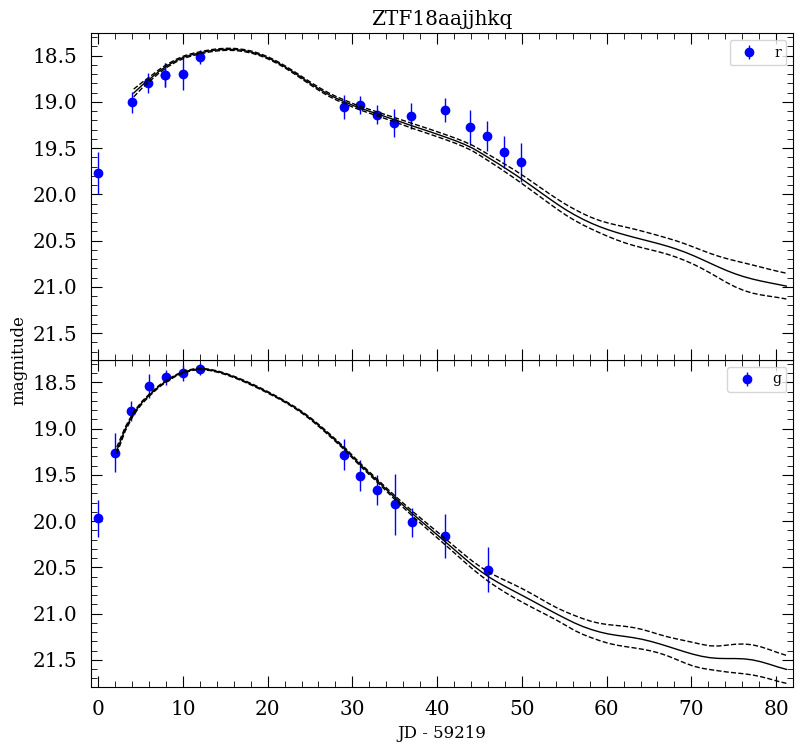

In [27]:
s.choose_model("max_model", stype="dm15")
s.set_restbands()
s.fit()
s.summary()